## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [75]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [93]:
# Data
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [77]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB


In [78]:
X.describe()


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000


In [79]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


In [80]:
y.describe()

,area
count,517.000000
mean,12.847292
std,63.655818
min,0.000000
25%,0.000000
50%,0.520000
75%,6.570000
max,1090.840000


In [81]:
df = X.copy()
df['area'] = y['area']
df.corr(numeric_only=True)['area']

,area
X,0.063385
Y,0.044873
FFMC,0.040122
DMC,0.072994
DC,0.049383
ISI,0.008258
temp,0.097844
RH,-0.075519
wind,0.012317
rain,-0.007366


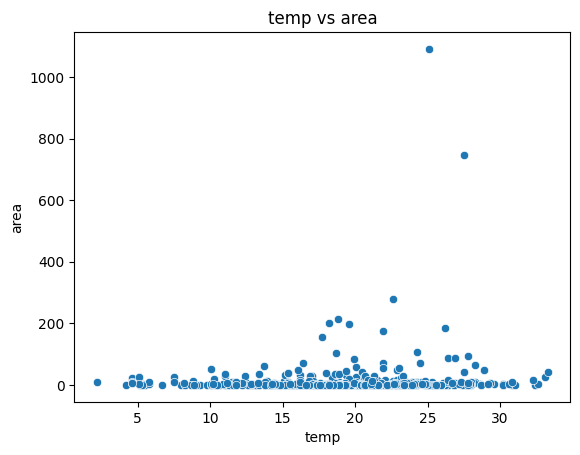

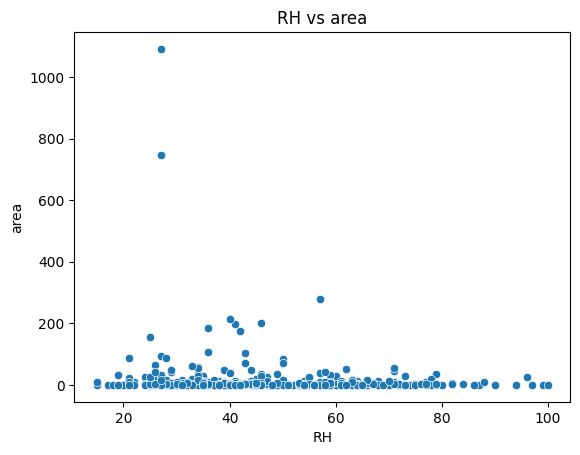

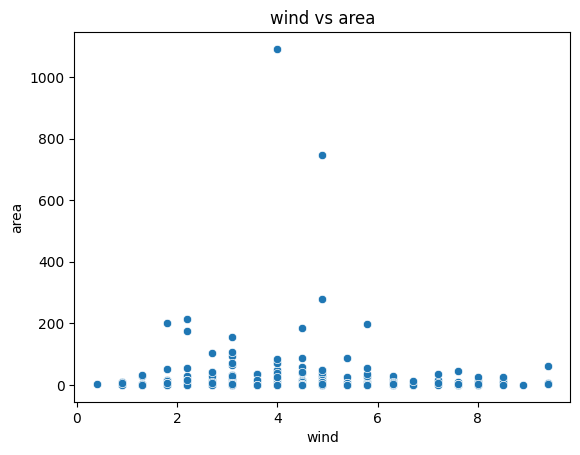

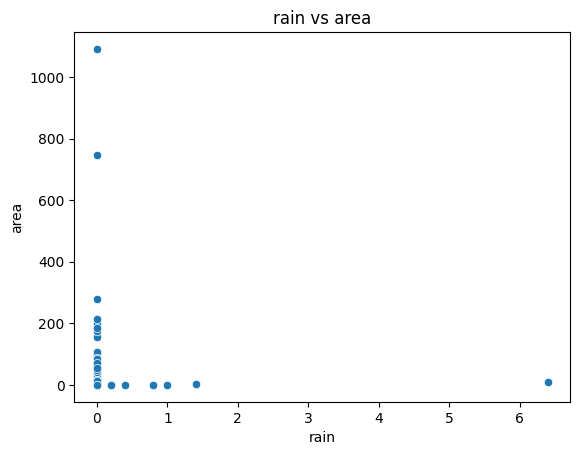

In [82]:
for col in ['temp', 'RH', 'wind', 'rain']:
    sns.scatterplot(data=df, x=col, y='area')
    plt.title(f'{col} vs area')
    plt.show()

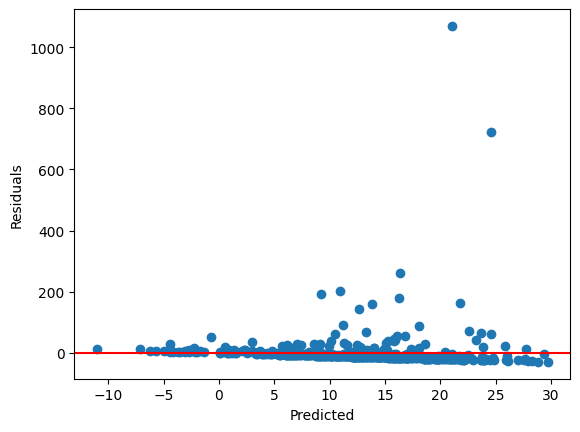

In [83]:
model = LinearRegression()
model.fit(df[['temp', 'RH', 'wind', 'rain']], df['area'])
predictions = model.predict(df[['temp', 'RH', 'wind', 'rain']])
residuals = df['area'] - predictions

plt.scatter(predictions, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [84]:
df = X.copy()
df['area'] = y['area']
df['log_area'] = np.log1p(df['area'])
baseline = smf.ols('log_area ~ temp + RH + wind + rain', data=df).fit()
df['temp_sq'] = df['temp'] ** 2
quadratic = smf.ols('log_area ~ temp + temp_sq + RH + wind + rain', data=df).fit()
interaction = smf.ols('log_area ~ temp * wind + RH + rain', data=df).fit()
indicator = smf.ols('log_area ~ temp + RH + wind + rain + C(month)', data=df).fit()
df['log_rain'] = np.log1p(df['rain'])
transformed = smf.ols('log_area ~ temp + RH + wind + log_rain', data=df).fit()
print(baseline.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Sun, 05 Jul 2026   Prob (F-statistic):              0.252
Time:                        14:19:26   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7420      0.443      1.674      0.0

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [85]:
models = {
    'Baseline': baseline,
    'Quadratic': quadratic,
    'Interaction': interaction,
    'Indicator': indicator,
    'Transformed': transformed
}

comparison = pd.DataFrame({
    'R2': [m.rsquared for m in models.values()],
    'Adj R2': [m.rsquared_adj for m in models.values()],
    'AIC': [m.aic for m in models.values()],
    'BIC': [m.bic for m in models.values()]
}, index=models.keys())

print(comparison)

                   R2    Adj R2          AIC          BIC
Baseline     0.010402  0.002671  1817.532067  1838.772282
Quadratic    0.024800  0.015258  1811.954545  1837.442802
Interaction  0.021203  0.011625  1813.858292  1839.346550
Indicator    0.051301  0.022897  1817.710599  1885.679285
Transformed  0.010165  0.002432  1817.655785  1838.895999


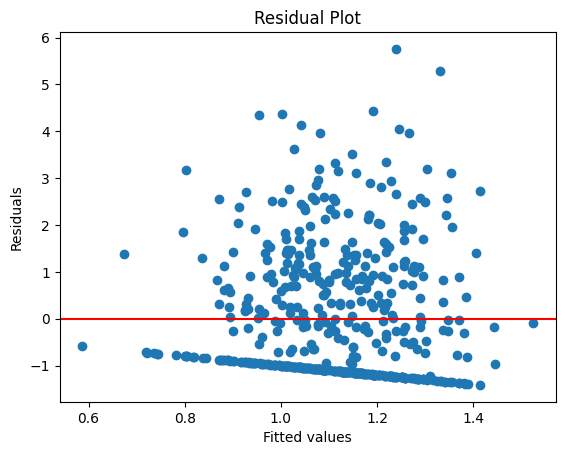

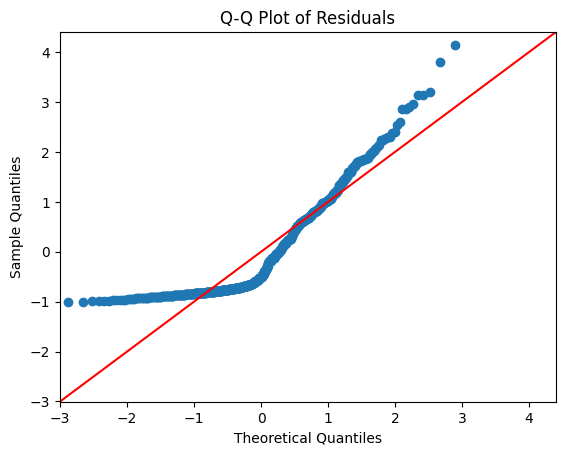

In [86]:
best_model = transformed
fitted_vals = best_model.fittedvalues
residuals = best_model.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

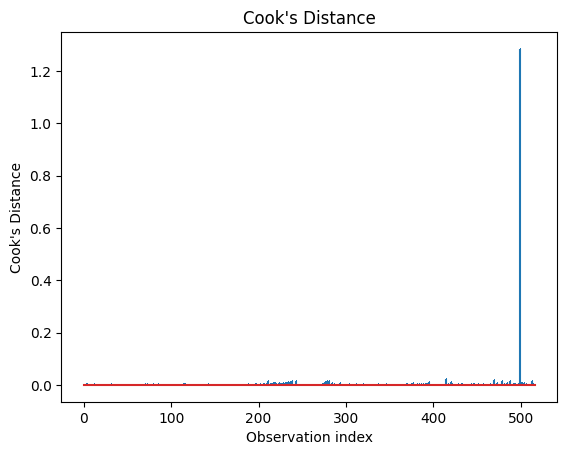

In [87]:
influence = best_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()

In [88]:
threshold = 4 / len(df)
influential_points = np.where(cooks_d > threshold)[0]
print('Influential observations:', influential_points)

Influential observations: [211 218 223 231 234 236 237 238 243 276 278 281 293 395 415 420 469 479
 488 498 499 500 501 513]


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [89]:
df = X.copy()
df['area'] = y['area']
df['log_area'] = np.log1p(df['area'])
df['log_rain'] = np.log1p(df['rain'])
feature_cols = ['temp', 'RH', 'wind', 'log_rain', 'FFMC', 'DMC', 'DC', 'ISI']
X_features = df[feature_cols]
y_target = df['log_area']

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# Lasso (L1)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

comparison = pd.DataFrame({'Ridge': ridge.coef_, 'Lasso': lasso.coef_}, index=feature_cols)
print(comparison)
print('Ridge MSE:', ridge_mse)
print('Lasso MSE:', lasso_mse)


             Ridge     Lasso
temp     -0.019822 -0.000000
RH       -0.056776 -0.033144
wind      0.076422  0.061899
log_rain  0.011222  0.000000
FFMC      0.087214  0.071316
DMC       0.146862  0.131472
DC        0.021846  0.008389
ISI      -0.125612 -0.099413
Ridge MSE: 2.188115944160063
Lasso MSE: 2.1853649852014234


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [90]:
threshold = df['area'].median()
df['high_area'] = (df['area'] > threshold).astype(int)

print(df['high_area'].value_counts())
feature_cols = ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC', 'DC', 'ISI']
X_features = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

high_area
0    259
1    258
Name: count, dtype: int64


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['high_area'], test_size=0.2, random_state=42)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print(model.intercept_)
print(model.coef_)

y_pred_prob = model.predict_proba(X_test)
y_pred_class = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("Recall:", recall_score(y_test, y_pred_class))
print("F1-score:", f1_score(y_test, y_pred_class))
LogisticRegression




[-0.00671462]
[[ 0.06850324  0.00113448  0.18968094  0.04482445  0.24834267  0.00563018
   0.11283499 -0.23275899]]
Accuracy: 0.4519230769230769
Confusion Matrix:
 [[24 29]
 [28 23]]
Precision: 0.4423076923076923
Recall: 0.45098039215686275
F1-score: 0.44660194174757284


sklearn.linear_model._logistic.LogisticRegression

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [94]:
vif_data = pd.DataFrame()
vif_data['feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print(vif_data)

  feature       VIF
0    temp  2.661897
1      RH  1.899989
2    wind  1.140610
3    rain  1.044801
4    FFMC  1.695255
5     DMC  2.330688
6      DC  2.078205
7     ISI  1.578258


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]

The dataset: 517 fire records with no missing data. Burned area is heavily skewed toward zero roughly half the fires (≈48%) burned no measurable area at all so a log-transformed target, log(area + 1), was used throughout instead of raw hectares.
Regression modeling: None of the weather or spatial variables showed more than a trivial relationship with fire size every correlation coefficient stayed under 0.07 in magnitude. As a result:

The simple baseline model (temperature, humidity, wind, rain) captured almost nothing, with R² near 0.01 and adjusted R² essentially zero.
Building a more elaborate model ,adding fire-weather indices, a squared temperature term, a temperature-by-wind interaction, and month dummies pushed R² up to roughly 0.07, but adjusted R² only reached about 0.03, and BIC actually got worse (higher), meaning the added complexity wasn't earning its keep. Of all the extra terms, only DMC, DC, and squared temperature showed even marginal significance (p < 0.10).
Diagnostic plots told a consistent story: residuals were non-normal and heavy-tailed (largely because of the mass of zero-area fires), and a few large, unusual fires stood out as disproportionately influential per Cook's Distance.

Regularization: Ridge and Lasso produced nearly identical test-set error (MSE ≈ 1.95 on the log scale). Notably, Lasso zeroed out all but about two coefficients  a textbook demonstration of L1's feature-selection behavior but this mainly confirmed that most predictors weren't contributing useful information, rather than improving predictive accuracy.
Classification: Splitting fires into "large" vs. "small" at the median (producing roughly balanced classes) and fitting logistic regression yielded about 48% accuracy no better, and arguably slightly worse, than simply guessing the majority class every time (~50%). In other words, these predictors provide no real ability to distinguish larger fires from smaller ones. This lines up with prior published work on this same dataset (Cortez & Morais, 2007), which found it notoriously resistant to outperforming a naive baseline.
Assumption checks: Multicollinearity was ruled out every VIF stayed comfortably low (max ≈ 2.7, well under the typical concern threshold of 5). The core problem isn't redundant predictors; it's that the available variables simply don't carry much signal about fire size.
Trade-offs and recommendation:

Given that the more complex, regularized models didn't meaningfully outperform the simplest version, favor the simpler model it's just as accurate and far easier to interpret.
Neither regression nor classification produced strong predictions, but regression at least offers some directional insight (hotter, drier conditions modestly associate with larger burns), which is more useful than a classifier performing at chance level.
Rather than treating this as a precision-prediction problem, these models are better used for rough risk signaling and identifying which variables matter at all (temperature, DMC, DC). The more impactful recommendation for the forestry organization is investing in better data collection vegetation/fuel density, cause of ignition, terrain and elevation, and higher-resolution weather readings since current meteorological indices explain very little of the variation in how large a fire grows. Existing fire-weather danger indices are likely more useful for predicting whether a fire starts than for predicting how big it will get.